In [1]:
using DifferentialEquations
using LinearAlgebra
using Plots

In [ ]:
n=10 #Number of particles

In [2]:
function update(du, u, p, t)
    r = reshape(u, (3, n))'
    v = reshape(du, (3, n))'
    
    a = F(r, v, t, M, G)
    
    #du[1:3n] .= vec(v')
    #du[3n+1:end] .= vec(a')
    return vec(a')
end


update (generic function with 1 method)

In [107]:
ff=1e0

1.0

$$\frac{r_0}{t_0^2}\frac{d^2{\mathbf{r}}}{d{t'}^2}=-\sum_{i\neq j}^{N}GM\frac{r_0}{r_0^3}\frac{(r_i-r_j)}{|r_i-r_j|^{3}}$$

$$\frac{d^2{\mathbf{r}}}{d{t'}^2}=-\sum_{i\neq j}^{N}GM\frac{t_0^2}{r_0^3}\frac{(r_i-r_j)}{|r_i-r_j|^{3}}$$

$$t_0=\sqrt{\frac{r_0^3}{GM}}$$


$$\frac{d^2{\mathbf{r}}}{d{t'}^2}=-\sum_{i\neq j}^{N}\frac{(r_i-r_j)}{|r_i-r_j|^{3}}$$

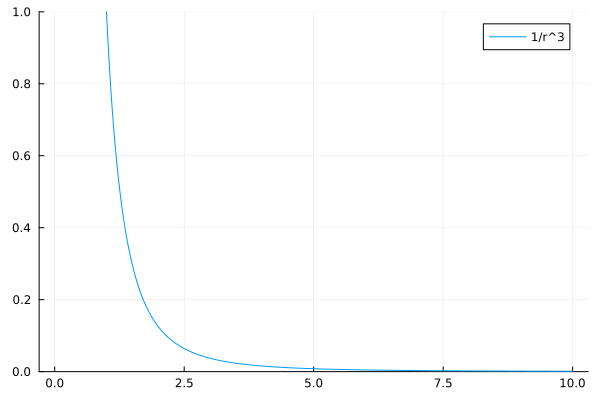

In [108]:
xxx=0:0.0001:10
plot(xxx,xxx.^(-3),ylims=(0,1),label="1/r^3")

In [316]:
function F(r, v, t, M, G)
    #n = size(r, 1)
    a = zeros(size(r))
    for i in 1:n
        for j in 1:n
            if i != j
                Rij = r[i, :] - r[j, :]
                nRij=1/norm(Rij)^3
                #if nRij<1
                 #   nRij=norm(Rij+5)^3
                #end
                #a[i,:]=[0,0,-0.2]
                a[i, :] += -ff * M[j] * Rij / nRij
            end
        end
    end
    return a
end


F (generic function with 1 method)

In [317]:
G = 39.478#1.505e4 #136.9#39.478
n = 10
L = 1.0 #AU
MM= 1.0 #Masa del sol
tp=sqrt(ff*L^3/(G*MM))##Time scaling factor
v0=6.283
vp=v0*tp/L
tf=1.0

#v0=7509 m/s
#r0 = [0,0,0,0,-1.0,0] #[0,0,0,0,-1.0,0]#[0.0,0.0,0.0,0.0,-1.0,0.0,0.0,-1.0-4.67921e-6,0.0]#
#v0 = [0,0.0,0,vp,0,0] #*[0,0,0,38.617,0,10]#[0,0,0,6.282,0,0,6.282+2.583,0,0]

r0=rand(3*n)
v0=zeros(3*n)#2.0 .* rand(3*n) .- 1.0

y0 = vcat(r0, v0)

M =ones(n)#[1,3.00273e-6] #[1,5.02e-25]#[1,3.00273e-6,1.5084e-30]#ones(n) ##ones(n)
p = (G, n, M)

tspan = (0.0, tf/tp);


In [318]:
prob =  SecondOrderODEProblem(update,v0,r0, tspan, p)
sol = solve(prob, VelocityVerlet(), saveat=0.01, maxiters=1e10,abstol=1e-12,reltol=1e-12,dt=1e-5);
states = sol.u;
ts=sol.t*tp;
MM=size(ts)[1]
Y = ones(Float64,MM, 3n)

 #Fill it
for i in 1:MM
    Y[i, :] = Float64.(sol.u[i][3n+1:end])#sol.u[i][3*n+1:end]
end

xs=Y[:,1:3:n*3]
ys=Y[:,2:3:n*3+1]
zs=Y[:,3:3:n*3+2];

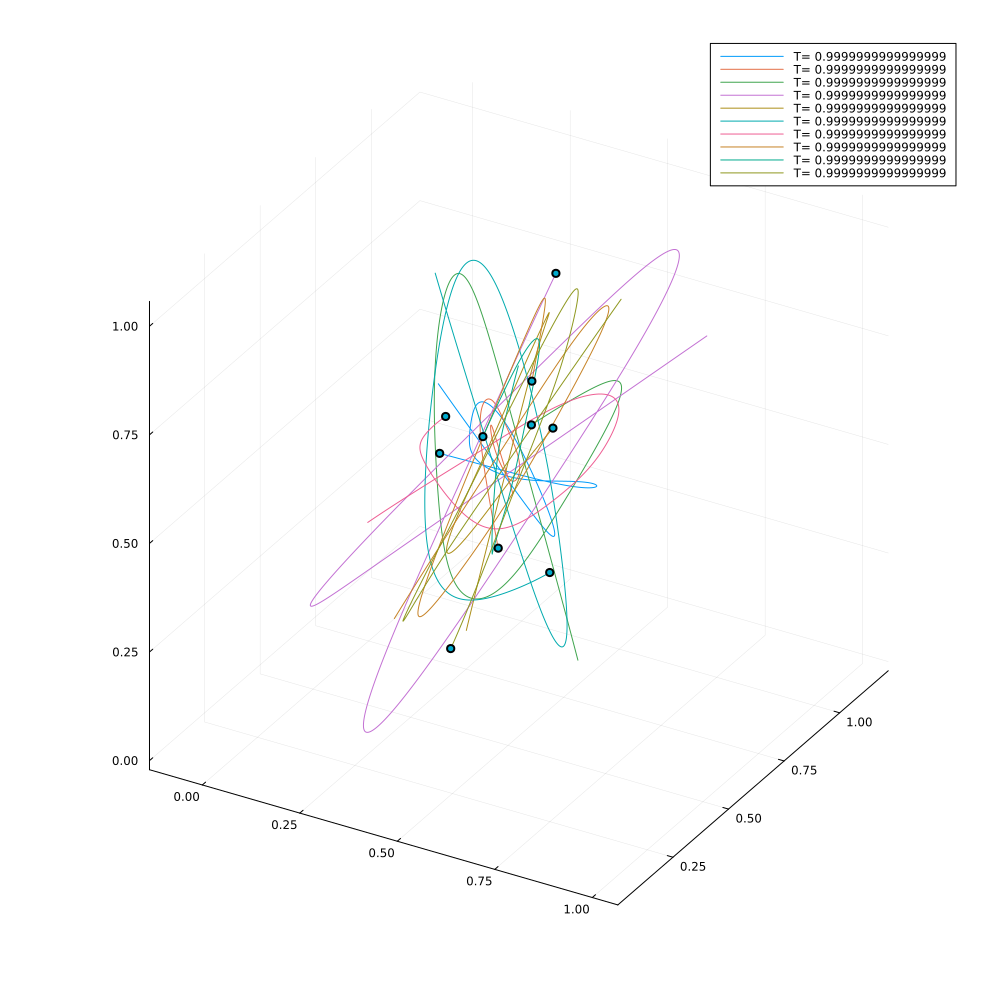

In [319]:
#plot(xs1,ys1,zs1,size=(1000,1000),title=string(n)*"-  Euler Bodies",xlabel="x",ylabel="y",zlabel="z",grid=:on)
plot(xs,ys,zs,size=(1000,1000),label="T= "*string(tspan[2]*tp),aspect_ratio=:equal)
scatter!(xs[end,:],ys[end,:],zs[end,:],label="")

[ Info: Saved animation to c:\Users\sesa813493\Documents\Juliakern\ebody_1.gif


Plots.AnimatedGif("c:\\Users\\sesa813493\\Documents\\Juliakern\\ebody_1.gif")
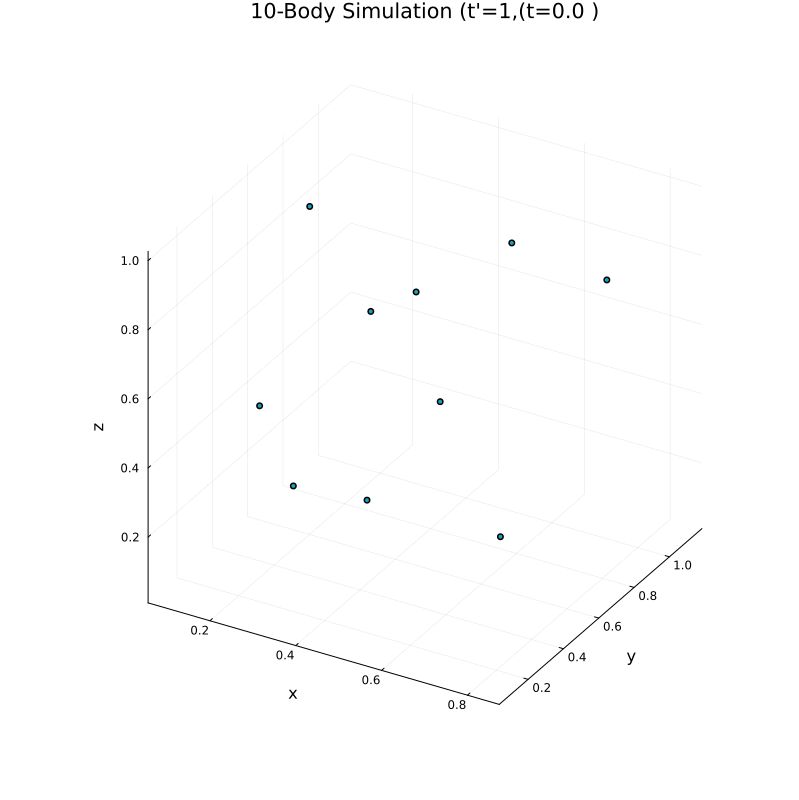

In [335]:
anim = @animate for t in 1:10:size(xs, 1)
    plot(xs[1:t, :], ys[1:t, :], zs[1:t, :],
        xlim = extrema(xs),
        ylim = extrema(ys),
        zlim = extrema(zs),
        legend = false,
        title = "$(n)-Body Simulation (t'=$(t),(t=$(round(t/size(xs,1)*tp,digits=3)) )",
        xlabel = "x", ylabel = "y", zlabel = "z",
        size=(800,800))

    plot!(xs[t, :], ys[t, :], zs[t, :],seriestype = :scatter,markersize = 3)
end

# Save or display
gif(anim, "ebody_1.gif", fps=30)

In [331]:
round(1*tp,digits=2)

0.16

In [333]:
ts

630-element Vector{Float64}:
 0.0
 0.0015915578487240574
 0.0031831156974481147
 0.004774673546172172
 0.006366231394896229
 0.007957789243620287
 0.009549347092344344
 0.0111409049410684
 0.012732462789792459
 0.014324020638516516
 0.01591557848724057
 0.01750713633596463
 0.019098694184688687
 ⋮
 0.9835827505114674
 0.9851743083601914
 0.9867658662089155
 0.9883574240576396
 0.9899489819063636
 0.9915405397550876
 0.9931320976038117
 0.9947236554525358
 0.9963152133012598
 0.9979067711499838
 0.9994983289987079
 0.9999999999999999